<div align="center">
    <h1> Control Barrier Functions in Semi-Automated Beverage Blending Equipment<br> 
    <h3> Samantha Becvar <br> University of Washington, Department of Mechanical Engineering Master's Program <br> A A/E E/M E 548 B <br> Prof. Karen Leung
</div>

## **----Section 0: Imports----**

In [9]:
import matplotlib.pyplot as plt
plt.ioff()
import ipynb
from ipynb.fs.full.Sec1_Build_The_Sys import *
from ipynb.fs.full.Sec2_Basic_PD_Controller import *
plt.ion()

## **----Section 3: CLF-CBF Filter----**
In this section, we will evolve our PD Controller into a controller with a CLF-CBF Filter 

#### Convert PD Controller into CLF Controller
**Functions:**
* clf_controller(state, y_des, y_des_dot, kp, kd)

**Equations:**
$$
\begin{bmatrix} e \\ \dot{e} \end{bmatrix} = \begin{bmatrix} y - y_{des} \\ \dot{y} - \dot{y}_{des} \end{bmatrix}
$$
$$
u_{nom} = -k_{p} e - k_{d} \dot{e}
$$

In [2]:
def clf_controller(
        state: Float[Array, "2"], 
        y_des: Float[Array, "1"],
        y_des_dot: Float[Array, "1"],
        kp=20.0,
        kd=10.0) -> Float[Array, "1"]:
    '''
    The purpose of this function is to create our nominal control value
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        y_des - desired position
        y_des_dot - desired velocity
        kp - proprtional gain value
        kd - derivative gain value
    Returns
        u_nom - our nominal control value
    '''
    # unpack our state
    y, y_dot = state

    # define our error terms
    e = y - y_des
    e_dot = y_dot - y_des_dot

    # compute our nominal control
    u_nom = -kp * e -kd * e_dot

    return u_nom

#### Define Bottom Barrier Function & Top Barrier Function

**Functions:**
* bottom_barrier(state, cup_geom)
* top_barrier(state, cup_geom)

**Bottom Barrier**
* safe set:   $y_{tip} > y_{bottom}$
* barrier:    $h_{b} = y_{tip} - y_{bottom}$
* constraint: $u + k_{1} \dot{h}_{b} + k_{2} h_{b} \geq 0$

**Top Barrier**
* safe set:   $y_{tip} < y_{top}$
* barrier:    $h_{t} = y_{top} - y_{tip}$
* constraint: $u - k_{1} \dot{h}_{t} - k_{2} h_{t} \geq 0$

In [3]:
def bottom_barrier(state: Float[Array, "2"], cup_geom: dict[str, Any]):
    ''' 
    The purpose of this function is define the bottom barrier geometry.
    For creating the bottom barrier definition, not called directly in simulation.
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        cup_geom - a dictionary of the cup geometry
    Returns
        h_b - bottom position barrier
        h_b_dot - bottom velocity barrier
    '''
    # unpack state
    y, y_dot = state
    
    # create blender geometry based on current state of blender
    blender_geom = blender_geometry(y)
    tip = blender_geom["tip_y"]

    # define our bottom barrier
    h_b = tip - (cup_geom["cup_bottom_y"] + 0.5)
    # define our bottom barrier velocity
    h_b_dot = y_dot

    return h_b, h_b_dot

def top_barrier(state: Float[Array, "2"], cup_geom: dict[str, Any]):
    ''' 
    The purpose of this function is define the top barrier geometry.
    For creating the top barrier definition, not called directly in simulation.
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        cup_geom - a dictionary of the cup geometry
    Returns
        h_t - top position barrier
        h_t_dot - top velocity barrier
    '''
    # unpack state
    y, y_dot = state

    # create blender geometry based on current state of blender
    blender_geom = blender_geometry(y)
    tip = blender_geom["tip_y"]

    # define our top barrier
    h_t = (cup_geom["cup_top_y"] - 0.5) - tip
    # define our top barrier velocity
    h_t_dot = -y_dot

    return h_t, h_t_dot

#### Define the CBF Filter

**Bottom Barrier Constraint:**
* $u_{lower} + k_1\dot{h}_{b} + k_0h_{b} \geq 0$

**Top Barrier Constraint:**
* $-u_{upper} + k_1\dot{h}_{b} + k_0h_{b} \geq 0$

**Complete Constraint:**
* $u_{lower} \leq u \leq u_{upper}$

In [4]:
def cbf_filter(
        state: Float[Array, "2"], 
        u_nom: float, 
        cup_geom: dict[str, Any], 
        k0=20.0, 
        k1=14.0, 
        u_min = -30.0, 
        u_max = 30.0,
        enforce_cup = False) -> float:
    ''' 
    The purpose of this function is to create our CBF filter.
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        u_nom - the nominal control calulcated from the CLF controller
        cup_geom - a dictionary of the cup geometry
        k0 - tuning gain for position
        k1 - tuning gain for velocity
        u_min - minimum control, actuator limits
        u_max - maximum control, actuator limits
    Returns
    '''
    # define our bottom barrier constraint
    h_b, h_b_dot = bottom_barrier(state, cup_geom)
    u_lower = -(k1 * h_b_dot + k0 * h_b)

    # define our top barrier constraint
    h_t, h_t_dot = top_barrier(state, cup_geom)
    u_upper = k1 * h_t_dot + k0 * h_t

    # define the control constraints due to acuator limits
    lower = jnp.maximum(u_lower, u_min)
    upper = jnp.minimum(u_upper, u_max)

    # safe control
    if enforce_cup:
        u_safe = jnp.clip(
            u_nom,
            lower,
            upper
        )
    elif not enforce_cup:
        u_safe = jnp.clip(
            u_nom,
            u_min,
            u_max
        )

    return u_safe

In [5]:
def desired_state(cup_dims: Float[Array, "4"], home: float, t: float, T: float):
    '''
    The purpose of this function is to create our desired state--our "blending profile"
    -----
    Args
        home - the starting position of the blender tip
        t - time
    Returns
        y_des - desired position of the blender
        y_des_dot - desired velocity of the blender
    '''
    # greate our cup geometry
    cup_geom = cup_geometry(cup_dims)
    enforce_cup = True # default
    
    # use the cup dimensions to build our blend stroke
    center = (cup_geom["cup_top_y"] - cup_geom["cup_bottom_y"]) / 2.0
    amplitude = (center / 2.0)
    omega = 2 * jnp.pi * 0.7

    cup_top = cup_geom["cup_top_y"] - 0.5
    cup_bottom = cup_geom["cup_bottom_y"] + 0.5

    # timing
    per_10 = T * 0.1    # 10% of time
    per_20 = T * 0.2    # 20% of time
    per_70 = T * 0.7    # 70% of time    
    per_80 = T * 0.8    # 80% of time
    per_90 = T * 0.9    # 90% of time

    # Start at Home
    if t < per_10:
        y_des = home       
        y_des_dot = 0.0     

    # Approach the Cup
    elif t < per_20:
        y_des = cup_top   
        y_des_dot = -1.0    

    # Blend Stroke
    elif t < per_70:

        y_des = (center + amplitude * jnp.sin(omega * (t - 3.0)))
        y_des_dot = (amplitude * omega * jnp.cos(omega * (t - 3.0)))

    # Prepare to Leave Cup
    elif t < per_80:
        y_des = cup_top
        y_des_dot = 1.0

    # Retract back Home
    elif t < per_90:
        enforce_cup = False
        y_des = home
        y_des_dot = 1.0
    
    # Be Home
    else:
        enforce_cup = False
        y_des = home
        y_des_dot = 0.0

    return y_des, y_des_dot, enforce_cup

#### Stop & Check: CLF-CBF Filter

In [6]:
''' Set-Up for our Simulated PD Controller '''
# define our time
T = 12.0
DT = 0.01
# define our steps
N = int(T / DT)
# define our state
state_cbf = jnp.array([14.0, 0.0])
home_cbf = state_cbf[0]
# define our cup geometry
cup_dims_cbf = jnp.array([
    5,  # bottom width
    7,  # top width
    0,  # center location
    10  # height
])
cup_geom_cbf = cup_geometry(cup_dims_cbf)

# set-up our book keeping arrays
times_cbf = []
positions_cbf = []
velocities_cbf = []
nominal_controls_cbf = []
safe_controls_cbf = []

''' Run our Simulated CBF Controller'''
for k in range(N):
    # define our time
    t = k * DT

    # create our desired state for the time
    y_des, y_des_dot, enforce_cup = desired_state(cup_dims_cbf, home_cbf, t, T)

    # crete our nominal control
    u_nom = clf_controller(
        state_cbf, 
        y_des,
        y_des_dot
    )

    # create our control
    u = cbf_filter(
        state_cbf,
        u_nom,
        cup_geom_cbf,
        enforce_cup
    )

    # update our state
    state_cbf = integrate(
        state_cbf,
        u,
        DT
    )

    times_cbf.append(t)
    positions_cbf.append(state_cbf[0])
    velocities_cbf.append(state_cbf[1])
    nominal_controls_cbf.append(u_nom)
    safe_controls_cbf.append(u)

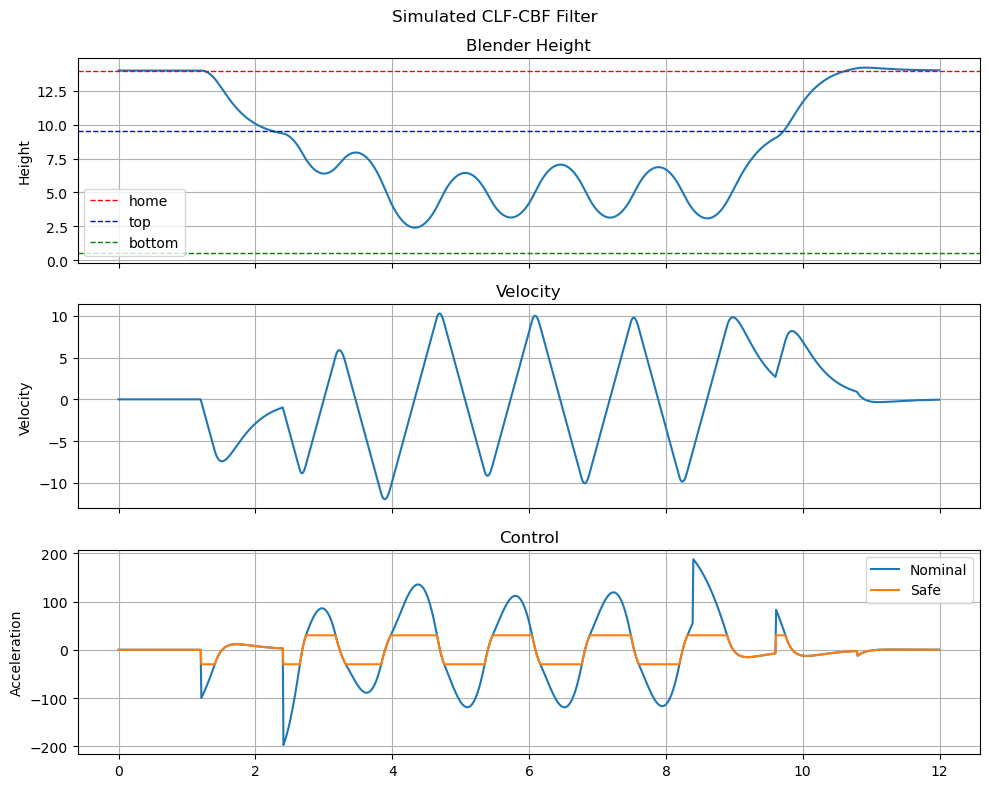

In [7]:
''' Create Plots of our Simulated CLF-CBF Filter'''
# create our figure and axes
fig_cbf, axs_cbf = plt.subplots(
    3,
    1,
    figsize=(10, 8),
    sharex = True
)

# Positions
axs_cbf[0].plot(times_cbf, positions_cbf)
axs_cbf[0].set_ylabel("Height")
axs_cbf[0].set_title("Blender Height")
axs_cbf[0].axhline(
        home,
        color='red',
        linestyle='--',
        linewidth=1,
        label="home"
    )
axs_cbf[0].axhline(
        9.5,
        color='blue',
        linestyle='--',
        linewidth=1,
        label="top"
    )
axs_cbf[0].axhline(
        0.5,
        color='green',
        linestyle='--',
        linewidth=1,
        label="bottom"
    )
axs_cbf[0].legend()

# Velocities
axs_cbf[1].plot(times_cbf, velocities_cbf)
axs_cbf[1].set_ylabel("Velocity")
axs_cbf[1].set_title("Velocity")

# Controls / Accelerations
axs_cbf[2].plot(
    times_cbf,
    nominal_controls_cbf,
    label='Nominal'
)

axs_cbf[2].plot(
    times_cbf,
    safe_controls_cbf,
    label='Safe'
)

axs_cbf[2].legend()
axs_cbf[2].set_ylabel("Acceleration")
axs_cbf[2].set_title("Control")

for ax in axs_cbf:
    ax.grid(True)

fig_cbf.suptitle("Simulated CLF-CBF Filter")
plt.tight_layout()
plt.show()

MovieWriter Pillow unavailable; using Pillow instead.


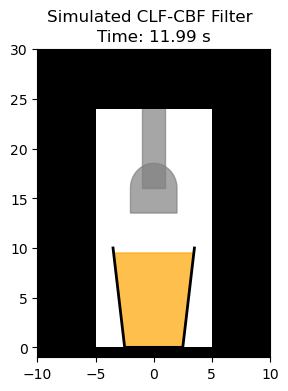

In [8]:
''' Animate our Simulated CBF Controller '''
''' Definitions '''
# environment dimensions
env_dims_cbf = jnp.array([
    [-10, 10],    # (x_min, x_max)
    [-1, 30]    # (y_min, y_max)
])
# black box dimensions
box_sizes_cbf = jnp.array([
    [10, 1],    # bottom box, (width, height)
    [14, 6],    # top box, (width, height)
    [5, 32],    # left box, (width, height)
    [5, 32]    # right box, (width, height)
])
box_centers_cbf = jnp.array([
    [0, -0.5],  # bottom box, (center_x, center_y)
    [0, 27],    # top box, (center_x, center_y) 
    [-7.5, 14], # left box, (center_x, center_y)
    [7.5, 14]  # right box, (center_x, center_y)
])
# cup dimensions
cup_dims_cbf = jnp.array([
    5,  # bottom width
    7,  # top width
    0,  # center location
    10  # height
])

''' Create the Plot '''
# create the figure and axis
fig2_cbf, ax2_cbf = plt.subplots(figsize=(3, 4))
fig2_cbf.suptitle("Simulated CLF-CBF Filter")

''' Create the Animation '''
def animate(frame):

    ax2_cbf.clear()

    draw_environment(
        ax2_cbf,
        env_dims_cbf,
        box_sizes_cbf,
        box_centers_cbf,
        cup_dims_cbf,
        "orange"
    )

    blender_height_cbf = positions_cbf[frame]
    blender(ax2_cbf, blender_height_cbf)

    ax2_cbf.grid(False)
    ax2_cbf.set_title(
        f"Time: {times_cbf[frame]:.2f} s"
    )

ani = FuncAnimation(
    fig2_cbf,
    animate,
    frames=len(positions_cbf),
    interval=30
)

ani.save("clf_cbf_filter_animation.gif", writer="Pillow", fps=30)

# HTML(ani.to_jshtml())